# LAB 1 - Bonus Track

Additional analysis for resonator (K), integrator (L) and bistability (P).


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from izhikevich_tools import IzhikevichConfig, simulate


In [2]:
OUT = PROJECT_ROOT / "figures" / "bonus"
OUT.mkdir(parents=True, exist_ok=True)


def plot_bonus(trace, title, path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

    axes[0].plot(trace.time, trace.v, lw=0.9, label="membrane v")
    axes[0].plot(trace.time, trace.current - 30, lw=0.8, color="red", alpha=0.75, label="input current (shifted)")
    axes[0].set_title(f"{title} - temporal response")
    axes[0].set_xlabel("Time (ms)")
    axes[0].set_ylabel("v")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(trace.v, trace.u, lw=0.9, color="purple")
    axes[1].set_title(f"{title} - phase portrait")
    axes[1].set_xlabel("v")
    axes[1].set_ylabel("u")
    axes[1].grid(alpha=0.25)

    fig.tight_layout()
    fig.savefig(path, dpi=140, bbox_inches="tight")
    plt.show()


## Resonator (K)


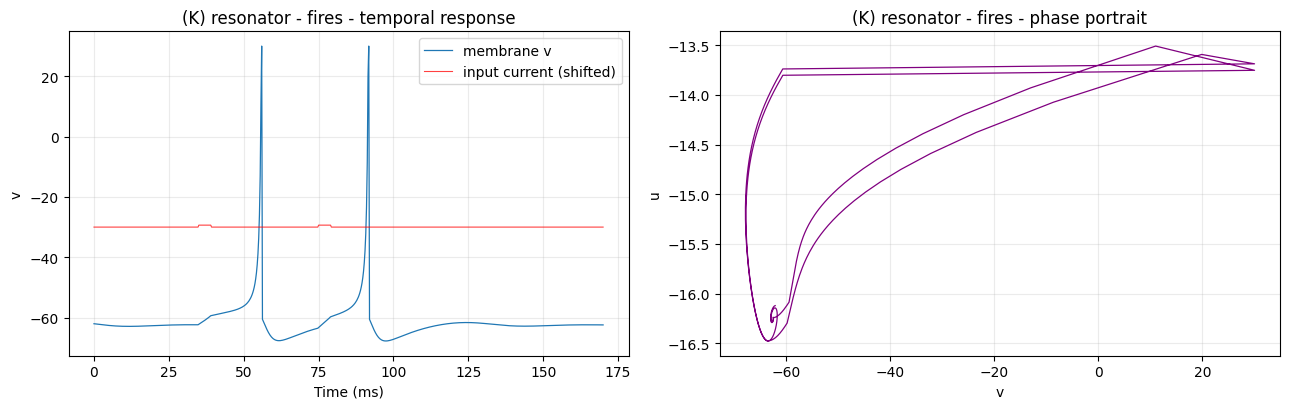

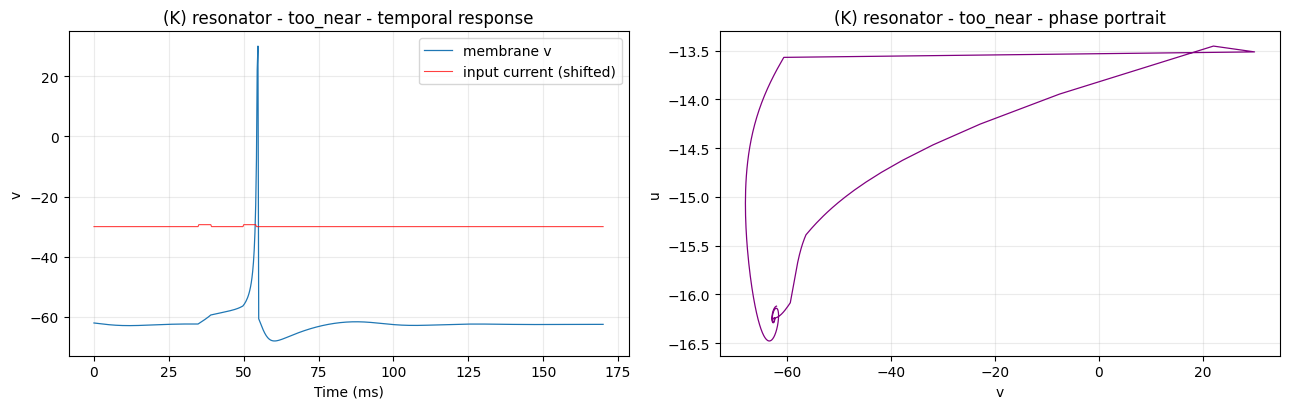

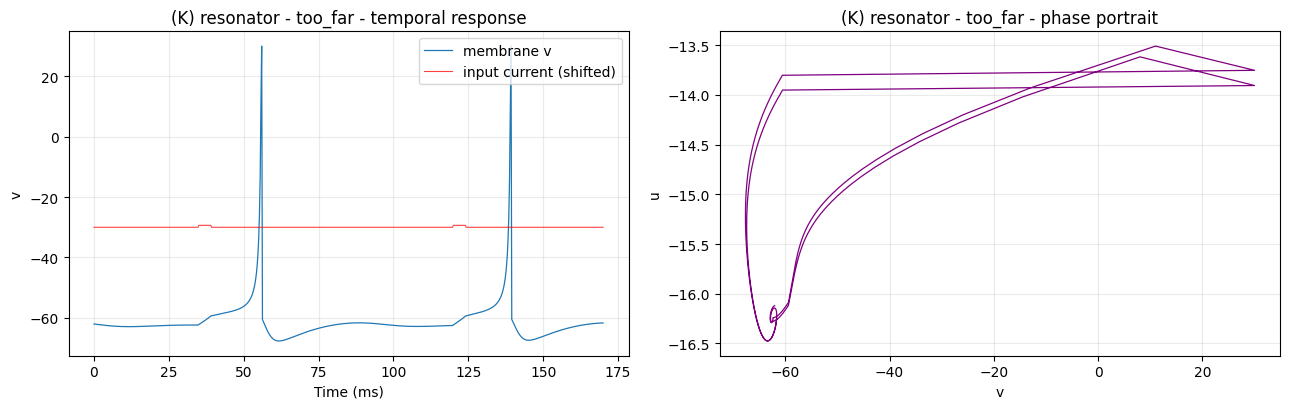

In [3]:
cfg_k = IzhikevichConfig(a=0.1, b=0.26, c=-60, d=-1, v0=-62)

cases_k = {
    "fires": [(35, 39), (75, 79)],
    "too_near": [(35, 39), (50, 54)],
    "too_far": [(35, 39), (120, 124)],
}

for label, windows in cases_k.items():
    current_fn = lambda t, w=windows: 0.65 if any(a <= t <= b for a, b in w) else 0.0
    tr = simulate(cfg_k, current_fn, t_stop=170, dt=0.25)
    plot_bonus(tr, f"(K) resonator - {label}", OUT / f"k_resonator_{label}.png")


## Integrator (L)


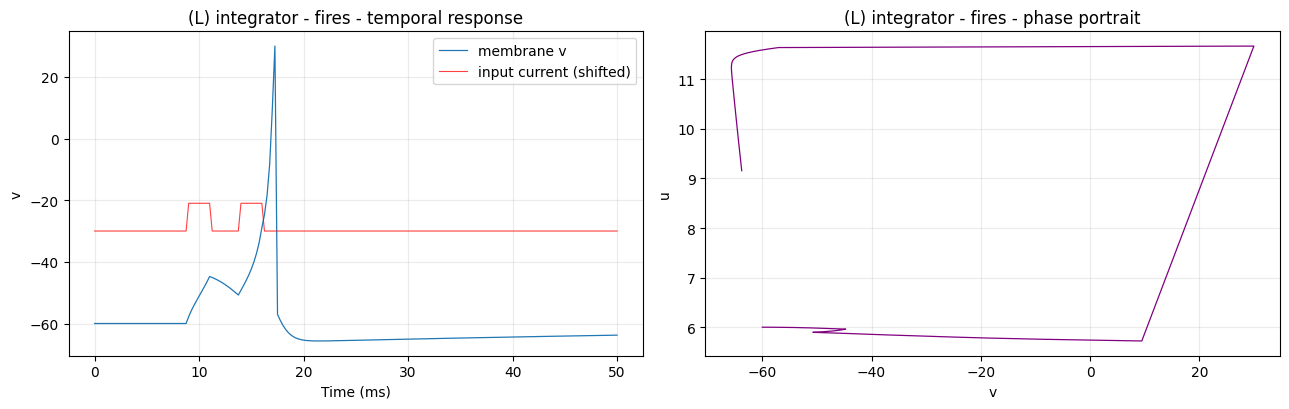

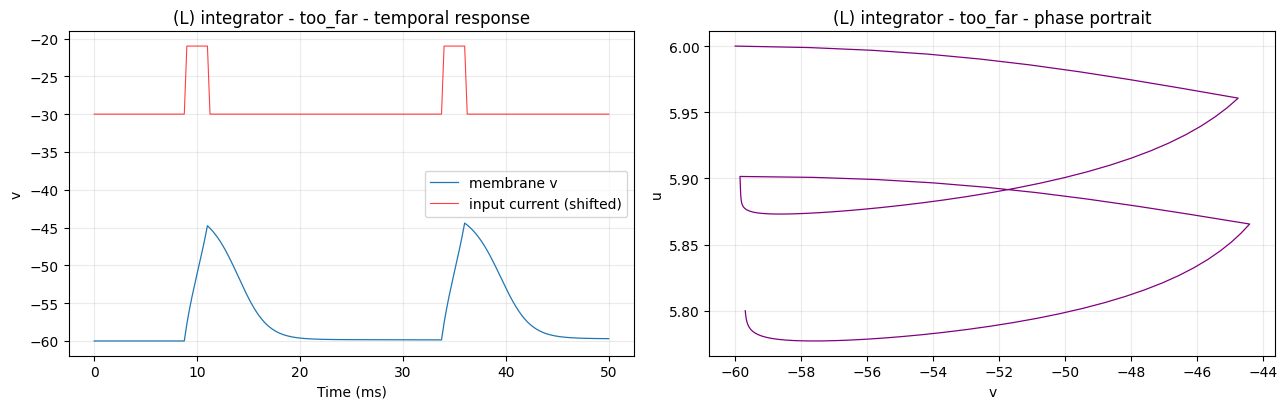

In [4]:
cfg_l = IzhikevichConfig(a=0.02, b=-0.1, c=-55, d=6, v0=-60, k_v=4.1, k_0=108)

cases_l = {
    "fires": [(9, 11), (14, 16)],
    "too_far": [(9, 11), (34, 36)],
}

for label, windows in cases_l.items():
    current_fn = lambda t, w=windows: 9.0 if any(a <= t <= b for a, b in w) else 0.0
    tr = simulate(cfg_l, current_fn, t_stop=50, dt=0.25)
    plot_bonus(tr, f"(L) integrator - {label}", OUT / f"l_integrator_{label}.png")


## Bistability (P)


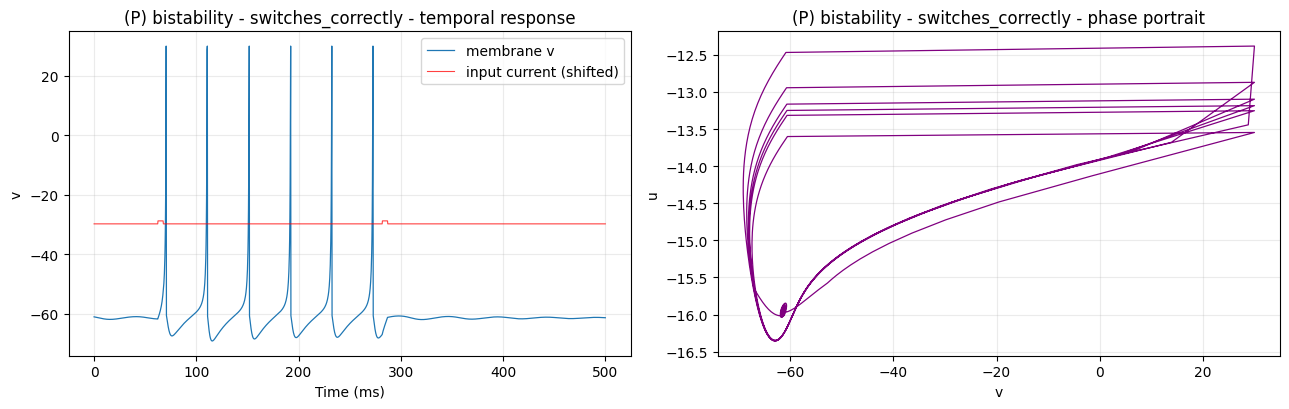

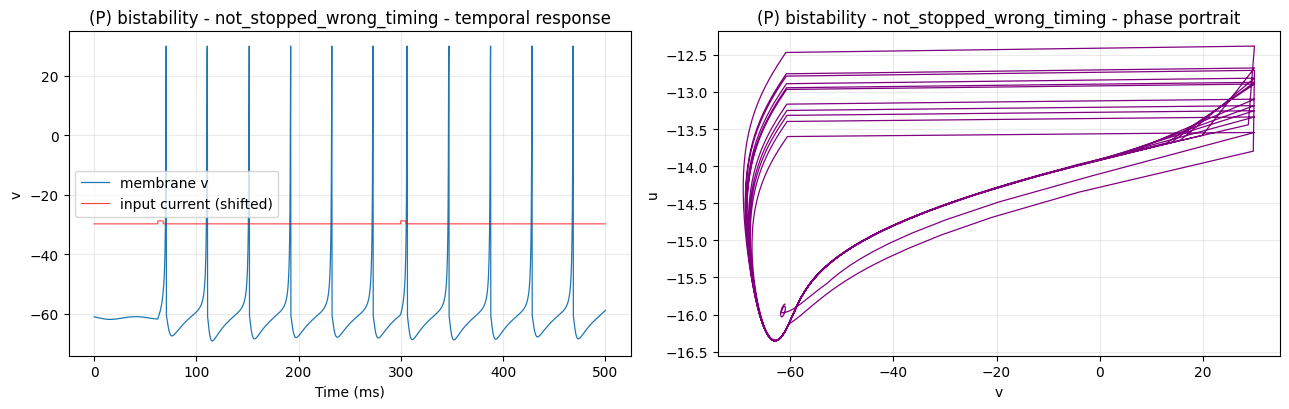

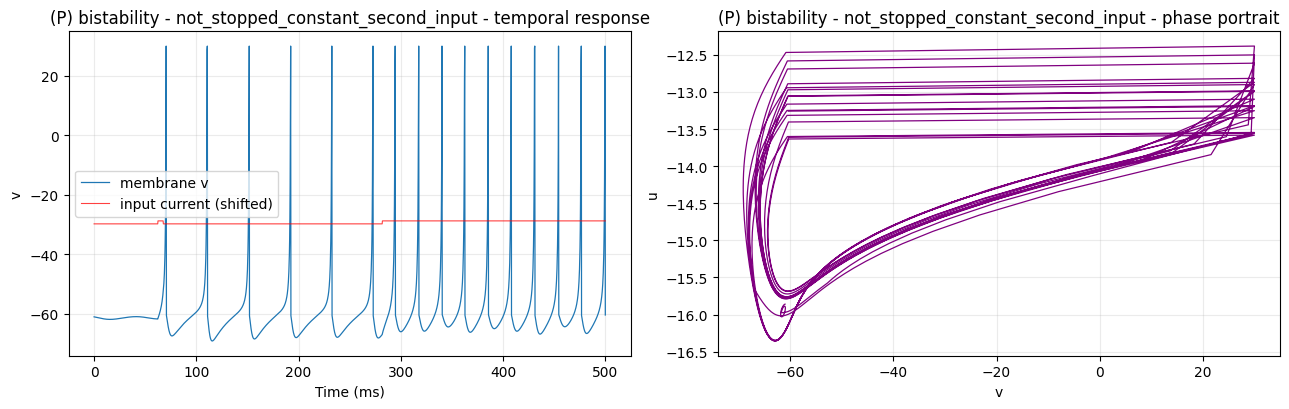

In [5]:
cfg_p = IzhikevichConfig(a=0.1, b=0.26, c=-60, d=0, v0=-61)

def pulse_current(windows, baseline=0.24, pulse=1.24):
    return lambda t: pulse if any(a <= t <= b for a, b in windows) else baseline

cases_p = {
    "switches_correctly": pulse_current([(62.5, 67.5), (282, 287)]),
    "not_stopped_wrong_timing": pulse_current([(62.5, 67.5), (300, 305)]),
    "not_stopped_constant_second_input": (lambda t: 1.24 if (62.5 <= t <= 67.5 or t >= 282) else 0.24),
}

for label, curr in cases_p.items():
    tr = simulate(cfg_p, curr, t_stop=500, dt=0.25)
    plot_bonus(tr, f"(P) bistability - {label}", OUT / f"p_bistability_{label}.png")
